In [ ]:
from google.colab import drive
drive.mount("/content/drive")

import os
import numpy as np
import torch

DATA_DIR = "/content/drive/MyDrive/Threat-detection/gnn_edge_data"
GRAPH_DIR = os.path.join(DATA_DIR, "prepared_graphs")
MODEL_DIR = os.path.join(DATA_DIR, "models")
RESULTS_DIR = os.path.join(DATA_DIR, "results")

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Device:", device)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Device: cuda


In [ ]:
# %pip install -q torch-geometric

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.4/64.4 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 32.8 MB/s eta 0:00:00


In [ ]:
## Loading training and validation graphs

train_graphs = torch.load(
    os.path.join(GRAPH_DIR, "train_graphs.pt"),
    weights_only=False
)

val_graphs = torch.load(
    os.path.join(GRAPH_DIR, "validation_graphs.pt"),
    weights_only=False
)

print("Training graphs:", len(train_graphs))
print("Validation graphs:", len(val_graphs))

Training graphs: 9300
Validation graphs: 10560


In [ ]:
### selecting attack samples

total_attacks = sum(
    int((graph.y == 1).sum())
    for graph in train_graphs
)

shot_counts = {
    "1_percent": round(total_attacks * 0.01),
    "5_percent": round(total_attacks * 0.05),
    "10_percent": round(total_attacks * 0.10),
}

print("Total training attacks:", total_attacks)
print("Few-shot counts:", shot_counts)

Total training attacks: 779
Few-shot counts: {'1_percent': 8, '5_percent': 39, '10_percent': 78}


While training , we will sample random group of normal events, if we give entire normal events with less attack samples then model will predict normal event all the time.

In [ ]:
## reusable lists of attack and normal edge locations

import numpy as np
from collections import defaultdict

rng = np.random.default_rng(42)

attacks_by_graph = defaultdict(list)
normal_pool = []

# Store each edge as: (graph number, edge number)
for graph_id, graph in enumerate(train_graphs):
    labels = graph.y.cpu().numpy()

    for edge_id, label in enumerate(labels):
        if label == 1:
            attacks_by_graph[graph_id].append(edge_id)
        else:
            normal_pool.append((graph_id, edge_id))

In [ ]:
## creating diverse attack order

attack_graph_ids = list(attacks_by_graph.keys())
rng.shuffle(attack_graph_ids)

attack_pool = []
remaining_attacks = []

# First take one attack from each attack window
for graph_id in attack_graph_ids:
    edge_ids = attacks_by_graph[graph_id].copy()
    rng.shuffle(edge_ids)

    attack_pool.append((graph_id, edge_ids[0]))

    for edge_id in edge_ids[1:]:
        remaining_attacks.append((graph_id, edge_id))

rng.shuffle(remaining_attacks)
attack_pool.extend(remaining_attacks)

# Shuffle the normal pool
rng.shuffle(normal_pool)

In [ ]:
## creating nested attack subsets

total_attacks = len(attack_pool)

shot_counts = {
    "1_percent": round(total_attacks * 0.01),
    "5_percent": round(total_attacks * 0.05),
    "10_percent": round(total_attacks * 0.10)
}

attack_subsets = {
    name: attack_pool[:count]
    for name, count in shot_counts.items()
}

print("Attack pool:", len(attack_pool))
print("Normal pool:", len(normal_pool))

for name, subset in attack_subsets.items():
    unique_windows = len(set(graph_id for graph_id, _ in subset))

    print(
        name,
        "| Attacks:", len(subset),
        "| Attack windows:", unique_windows
    )

Attack pool: 779
Normal pool: 150135
1_percent | Attacks: 8 | Attack windows: 8
5_percent | Attacks: 39 | Attack windows: 39
10_percent | Attacks: 78 | Attack windows: 78


In [ ]:
## one training epoch

import torch
from collections import defaultdict

def build_epoch_graphs(
    graphs,
    attack_refs,
    normal_pool,
    normal_ratio=10,
    seed=42
):
    rng = np.random.default_rng(seed)

    normal_count = len(attack_refs) * normal_ratio

    normal_indices = rng.choice(
        len(normal_pool),
        size=normal_count,
        replace=False
    )

    selected_normals = [
        normal_pool[index]
        for index in normal_indices
    ]

    selected_refs = attack_refs + selected_normals

    refs_by_graph = defaultdict(list)

    for graph_id, edge_id in selected_refs:
        refs_by_graph[graph_id].append(edge_id)

    epoch_graphs = []

    for graph_id, edge_ids in refs_by_graph.items():
        graph = graphs[graph_id].clone()
        edge_ids = torch.tensor(edge_ids, dtype=torch.long)

        graph.target_edge_index = graph.target_edge_index[:, edge_ids]
        graph.target_edge_attr = graph.target_edge_attr[edge_ids]
        graph.y = graph.y[edge_ids]

        if hasattr(graph, "target_row_ids"):
            graph.target_row_ids = graph.target_row_ids[edge_ids]

        epoch_graphs.append(graph)

    return epoch_graphs

In [ ]:
## testing with 1% attack subset

train_1pct_epoch = build_epoch_graphs(
    graphs=train_graphs,
    attack_refs=attack_subsets["1_percent"],
    normal_pool=normal_pool,
    normal_ratio=10,
    seed=42
)

labels = torch.cat([
    graph.y for graph in train_1pct_epoch
])

print("Graphs:", len(train_1pct_epoch))
print("Total labeled edges:", len(labels))
print("Attack edges:", int((labels == 1).sum()))
print("Normal edges:", int((labels == 0).sum()))

Graphs: 88
Total labeled edges: 88
Attack edges: 8
Normal edges: 80


In [ ]:
## Defining the GraphSAGE model used for training baseline

import torch.nn as nn
import torch.nn.functional as F

from torch_geometric.nn import SAGEConv
from torch_geometric.loader import DataLoader

class EdgeGraphSAGE(nn.Module):
    def __init__(
        self,
        node_features=6,
        edge_features=10,
        hidden_size=64,
        dropout=0.2
    ):
        super().__init__()

        self.conv1 = SAGEConv(node_features, hidden_size)
        self.conv2 = SAGEConv(hidden_size, hidden_size)

        self.classifier = nn.Sequential(
            nn.Linear(hidden_size * 2 + edge_features, hidden_size),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_size, 1)
        )

        self.dropout = dropout

    def forward(self, data):
        x = F.relu(self.conv1(data.x, data.edge_index))
        x = F.dropout(x, p=self.dropout, training=self.training)

        x = F.relu(self.conv2(x, data.edge_index))

        source = data.target_edge_index[0]
        destination = data.target_edge_index[1]

        edge_input = torch.cat([
            x[source],
            x[destination],
            data.target_edge_attr
        ], dim=1)

        return self.classifier(edge_input).squeeze(-1)

In [ ]:
## creating new model and testing on one batch

torch.manual_seed(42)
torch.cuda.manual_seed_all(42)

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

model = EdgeGraphSAGE().to(device)

train_loader = DataLoader(
    train_1pct_epoch,
    batch_size=64,
    shuffle=True
)

batch = next(iter(train_loader)).to(device)

with torch.no_grad():
    logits = model(batch)

print("Device:", device)
print("Predictions:", logits.shape)
print("Targets:", batch.y.shape)

Device: cuda
Predictions: torch.Size([64])
Targets: torch.Size([64])


### 1% few-shpt model

In [ ]:
from sklearn.metrics import (
    average_precision_score,
    precision_score,
    recall_score,
    f1_score
)

def train_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss, total_edges = 0, 0

    for batch in loader:
        batch = batch.to(device)

        optimizer.zero_grad()
        logits = model(batch)
        loss = criterion(logits, batch.y.float())

        loss.backward()
        optimizer.step()

        total_loss += loss.item() * batch.y.numel()
        total_edges += batch.y.numel()

    return total_loss / total_edges


def evaluate(model, loader):
    model.eval()
    probabilities, targets = [], []

    with torch.no_grad():
        for batch in loader:
            batch = batch.to(device)

            probabilities.append(
                torch.sigmoid(model(batch)).cpu()
            )
            targets.append(batch.y.cpu())

    probabilities = torch.cat(probabilities).numpy()
    targets = torch.cat(targets).numpy().astype(int)
    predictions = (probabilities >= 0.5).astype(int)

    return {
        "pr_auc": average_precision_score(targets, probabilities),
        "precision": precision_score(
            targets, predictions, zero_division=0
        ),
        "recall": recall_score(
            targets, predictions, zero_division=0
        ),
        "f1": f1_score(
            targets, predictions, zero_division=0
        )
    }

In [ ]:
## creating validation loader and starting fresh training

val_loader = DataLoader(
    val_graphs,
    batch_size=128,
    shuffle=False
)

torch.manual_seed(42)
torch.cuda.manual_seed_all(42)

model = EdgeGraphSAGE().to(device)

positive_weight = np.sqrt(10)

criterion = nn.BCEWithLogitsLoss(
    pos_weight=torch.tensor(
        [positive_weight],
        device=device
    )
)

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=3e-4,
    weight_decay=1e-3
)

BEST_1PCT_PATH = os.path.join(
    MODEL_DIR,
    "binary_graphsage_1pct.pt"
)

best_pr_auc = -1
patience = 5
waiting = 0

In [ ]:
## training loop

for epoch in range(1, 31):

    # Different normal samples every epoch
    epoch_graphs = build_epoch_graphs(
        train_graphs,
        attack_subsets["1_percent"],
        normal_pool,
        normal_ratio=10,
        seed=42 + epoch
    )

    train_loader = DataLoader(
        epoch_graphs,
        batch_size=32,
        shuffle=True
    )

    train_loss = train_epoch(
        model, train_loader, optimizer, criterion
    )

    train_metrics = evaluate(model, train_loader)
    val_metrics = evaluate(model, val_loader)

    print(
        f"Epoch {epoch:02d} | "
        f"Loss {train_loss:.4f} | "
        f"Train F1 {train_metrics['f1']:.4f} | "
        f"Val F1 {val_metrics['f1']:.4f} | "
        f"Val PR-AUC {val_metrics['pr_auc']:.4f}"
    )

    if val_metrics["pr_auc"] > best_pr_auc:
        best_pr_auc = val_metrics["pr_auc"]
        waiting = 0

        torch.save({
            "epoch": epoch,
            "model_state_dict": model.state_dict(),
            "validation_pr_auc": best_pr_auc,
            "attack_percentage": 1
        }, BEST_1PCT_PATH)

    else:
        waiting += 1

    if waiting >= patience:
        print("Early stopping")
        break

Epoch 01 | Loss 0.8392 | Train F1 0.1905 | Val F1 0.7171 | Val PR-AUC 0.8754
Epoch 02 | Loss 0.7465 | Train F1 0.0000 | Val F1 0.7989 | Val PR-AUC 0.8135
Epoch 03 | Loss 0.8224 | Train F1 0.0000 | Val F1 0.6189 | Val PR-AUC 0.7858
Epoch 04 | Loss 0.7327 | Train F1 0.1818 | Val F1 0.6470 | Val PR-AUC 0.8032
Epoch 05 | Loss 0.7193 | Train F1 0.1667 | Val F1 0.6411 | Val PR-AUC 0.7916
Epoch 06 | Loss 0.6789 | Train F1 0.1667 | Val F1 0.6614 | Val PR-AUC 0.7819
Early stopping


- Training contains only eight attack examples.
- The sampled training set changes every epoch.

In [ ]:
## best validation threshold for the checkpoint
from sklearn.metrics import precision_recall_curve

checkpoint = torch.load(
    BEST_1PCT_PATH,
    map_location=device,
    weights_only=False
)

model.load_state_dict(
    checkpoint["model_state_dict"]
)

model.eval()

val_probs, val_targets = [], []

with torch.no_grad():
    for batch in val_loader:
        batch = batch.to(device)

        val_probs.append(
            torch.sigmoid(model(batch)).cpu()
        )
        val_targets.append(batch.y.cpu())

val_probs = torch.cat(val_probs).numpy()
val_targets = torch.cat(val_targets).numpy().astype(int)

precision, recall, thresholds = precision_recall_curve(
    val_targets,
    val_probs
)

f1_scores = (
    2 * precision * recall
    / (precision + recall + 1e-8)
)

best_index = np.argmax(f1_scores[:-1])
best_threshold_1pct = thresholds[best_index]

print("Best epoch:", checkpoint["epoch"])
print("Validation PR-AUC:",
      checkpoint["validation_pr_auc"])
print("Best threshold:", best_threshold_1pct)
print("Precision:", precision[best_index])
print("Recall:", recall[best_index])
print("F1:", f1_scores[best_index])

Best epoch: 1
Validation PR-AUC: 0.8753775878279147
Best threshold: 0.54437643
Precision: 0.7460957834461218
Recall: 0.975128985315518
F1: 0.8453743325534068


- 97.5% of validation attacks were detected.
- 74.6% of alerts were correct.
- Best F1 was 84.5%.

In [ ]:
## creating 2 more 1% attack subsets

def select_attack_subset(
    attacks_by_graph,
    percentage,
    seed
):
    rng = np.random.default_rng(seed)

    graph_ids = list(attacks_by_graph.keys())
    rng.shuffle(graph_ids)

    ordered_attacks = []
    remaining_attacks = []

    # First select one attack from each window
    for graph_id in graph_ids:
        edge_ids = attacks_by_graph[graph_id].copy()
        rng.shuffle(edge_ids)

        ordered_attacks.append((graph_id, edge_ids[0]))

        for edge_id in edge_ids[1:]:
            remaining_attacks.append((graph_id, edge_id))

    rng.shuffle(remaining_attacks)
    ordered_attacks.extend(remaining_attacks)

    sample_count = round(
        len(ordered_attacks) * percentage
    )

    return ordered_attacks[:sample_count]

In [ ]:
attack_1pct_by_seed = {
    seed: select_attack_subset(
        attacks_by_graph,
        percentage=0.01,
        seed=seed
    )
    for seed in [42, 43, 44]
}

for seed, subset in attack_1pct_by_seed.items():
    print(
        "Seed:", seed,
        "| Attacks:", len(subset),
        "| Windows:",
        len(set(graph_id for graph_id, _ in subset))
    )

Seed: 42 | Attacks: 8 | Windows: 8
Seed: 43 | Attacks: 8 | Windows: 8
Seed: 44 | Attacks: 8 | Windows: 8


In [ ]:
## training for seed 43 and 44

from sklearn.metrics import precision_recall_curve

def run_1pct_experiment(seed):
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    model = EdgeGraphSAGE().to(device)

    criterion = nn.BCEWithLogitsLoss(
        pos_weight=torch.tensor(
            [np.sqrt(10)],
            device=device
        )
    )

    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=3e-4,
        weight_decay=1e-3
    )

    model_path = os.path.join(
        MODEL_DIR,
        f"binary_graphsage_1pct_seed_{seed}.pt"
    )

    best_pr_auc = -1
    waiting = 0

    for epoch in range(1, 31):
        epoch_graphs = build_epoch_graphs(
            train_graphs,
            attack_1pct_by_seed[seed],
            normal_pool,
            normal_ratio=10,
            seed=(seed * 100) + epoch
        )

        loader = DataLoader(
            epoch_graphs,
            batch_size=32,
            shuffle=True
        )

        train_loss = train_epoch(
            model, loader, optimizer, criterion
        )

        val_metrics = evaluate(model, val_loader)

        print(
            f"Seed {seed} | Epoch {epoch:02d} | "
            f"Loss {train_loss:.4f} | "
            f"Val PR-AUC {val_metrics['pr_auc']:.4f}"
        )

        if val_metrics["pr_auc"] > best_pr_auc:
            best_pr_auc = val_metrics["pr_auc"]
            waiting = 0

            torch.save({
                "epoch": epoch,
                "model_state_dict": model.state_dict(),
                "validation_pr_auc": best_pr_auc
            }, model_path)
        else:
            waiting += 1

        if waiting >= 5:
            break

    checkpoint = torch.load(
        model_path,
        map_location=device,
        weights_only=False
    )

    model.load_state_dict(
        checkpoint["model_state_dict"]
    )

    model.eval()
    probabilities, targets = [], []

    with torch.no_grad():
        for batch in val_loader:
            batch = batch.to(device)

            probabilities.append(
                torch.sigmoid(model(batch)).cpu()
            )
            targets.append(batch.y.cpu())

    probabilities = torch.cat(probabilities).numpy()
    targets = torch.cat(targets).numpy().astype(int)

    precision, recall, thresholds = precision_recall_curve(
        targets, probabilities
    )

    f1 = (
        2 * precision * recall
        / (precision + recall + 1e-8)
    )

    best_index = np.argmax(f1[:-1])

    return {
        "seed": seed,
        "best_epoch": checkpoint["epoch"],
        "pr_auc": checkpoint["validation_pr_auc"],
        "threshold": float(thresholds[best_index]),
        "precision": float(precision[best_index]),
        "recall": float(recall[best_index]),
        "f1": float(f1[best_index])
    }

In [ ]:
results_1pct = [{
    "seed": 42,
    "best_epoch": 1,
    "pr_auc": 0.8753775878279147,
    "threshold": 0.54437643,
    "precision": 0.7460957834461218,
    "recall": 0.975128985315518,
    "f1": 0.8453743325534068
}]

for seed in [43, 44]:
    result = run_1pct_experiment(seed)
    results_1pct.append(result)
    print("\nResult:", result)

Seed 43 | Epoch 01 | Loss 0.8095 | Val PR-AUC 0.3939
Seed 43 | Epoch 02 | Loss 0.7138 | Val PR-AUC 0.3692
Seed 43 | Epoch 03 | Loss 0.6261 | Val PR-AUC 0.3581
Seed 43 | Epoch 04 | Loss 0.6685 | Val PR-AUC 0.3532
Seed 43 | Epoch 05 | Loss 0.5402 | Val PR-AUC 0.3559
Seed 43 | Epoch 06 | Loss 0.5552 | Val PR-AUC 0.3814

Result: {'seed': 43, 'best_epoch': 1, 'pr_auc': np.float64(0.3939286912190217), 'threshold': 0.5016681551933289, 'precision': 0.4905722635995098, 'recall': 0.7867253793963677, 'f1': 0.6043159153959629}
Seed 44 | Epoch 01 | Loss 0.8248 | Val PR-AUC 0.8132
Seed 44 | Epoch 02 | Loss 0.7054 | Val PR-AUC 0.7539
Seed 44 | Epoch 03 | Loss 0.6608 | Val PR-AUC 0.7395
Seed 44 | Epoch 04 | Loss 0.6097 | Val PR-AUC 0.7203
Seed 44 | Epoch 05 | Loss 0.5467 | Val PR-AUC 0.7188
Seed 44 | Epoch 06 | Loss 0.5411 | Val PR-AUC 0.7151

Result: {'seed': 44, 'best_epoch': 1, 'pr_auc': np.float64(0.8131810673897216), 'threshold': 0.5171290040016174, 'precision': 0.8125391342988143, 'recall': 0.76

The large difference between seeds 42 and 43 tells:
- Eight attacks are not enough for consistent training.
- Performance depends heavily on which attacks are selected.
- All runs choosing epoch 1 also shows that the model quickly overfits these eight examples.

### 5% Few-shot

In [ ]:
## preparing 5% subsets

attack_5pct_by_seed = {
    seed: select_attack_subset(
        attacks_by_graph,
        percentage=0.05,
        seed=seed
    )
    for seed in [42, 43, 44]
}

for seed, subset in attack_5pct_by_seed.items():
    print(
        "Seed:", seed,
        "| Attacks:", len(subset),
        "| Windows:",
        len(set(graph_id for graph_id, _ in subset))
    )

Seed: 42 | Attacks: 39 | Windows: 39
Seed: 43 | Attacks: 39 | Windows: 39
Seed: 44 | Attacks: 39 | Windows: 39


In [ ]:
## optimized training function

def run_fewshot_experiment(percentage, seed):
    attack_refs = select_attack_subset(
        attacks_by_graph,
        percentage=percentage / 100,
        seed=seed
    )

    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    model = EdgeGraphSAGE().to(device)

    criterion = nn.BCEWithLogitsLoss(
        pos_weight=torch.tensor(
            [np.sqrt(10)],
            device=device
        )
    )

    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=3e-4,
        weight_decay=1e-3
    )

    model_path = os.path.join(
        MODEL_DIR,
        f"binary_graphsage_{percentage}pct_seed_{seed}.pt"
    )

    best_pr_auc = -1
    waiting = 0

    for epoch in range(1, 31):
        epoch_graphs = build_epoch_graphs(
            train_graphs,
            attack_refs,
            normal_pool,
            normal_ratio=10,
            seed=(seed * 100) + epoch
        )

        train_loader = DataLoader(
            epoch_graphs,
            batch_size=32,
            shuffle=True
        )

        train_loss = train_epoch(
            model,
            train_loader,
            optimizer,
            criterion
        )

        val_metrics = evaluate(model, val_loader)

        print(
            f"{percentage}% | Seed {seed} | "
            f"Epoch {epoch:02d} | "
            f"Loss {train_loss:.4f} | "
            f"PR-AUC {val_metrics['pr_auc']:.4f}"
        )

        if val_metrics["pr_auc"] > best_pr_auc:
            best_pr_auc = val_metrics["pr_auc"]
            waiting = 0

            torch.save({
                "percentage": percentage,
                "seed": seed,
                "epoch": epoch,
                "validation_pr_auc": best_pr_auc,
                "model_state_dict": model.state_dict()
            }, model_path)

        else:
            waiting += 1

        if waiting >= 5:
            print("Early stopping")
            break

    # Load the best epoch
    checkpoint = torch.load(
        model_path,
        map_location=device,
        weights_only=False
    )

    model.load_state_dict(
        checkpoint["model_state_dict"]
    )

    # Find the best validation threshold
    model.eval()
    probabilities, targets = [], []

    with torch.no_grad():
        for batch in val_loader:
            batch = batch.to(device)

            probabilities.append(
                torch.sigmoid(model(batch)).cpu()
            )
            targets.append(batch.y.cpu())

    probabilities = torch.cat(probabilities).numpy()
    targets = torch.cat(targets).numpy().astype(int)

    precision, recall, thresholds = precision_recall_curve(
        targets, probabilities
    )

    f1 = (
        2 * precision * recall
        / (precision + recall + 1e-8)
    )

    best_index = np.argmax(f1[:-1])

    return {
        "percentage": percentage,
        "seed": seed,
        "attacks_used": len(attack_refs),
        "best_epoch": checkpoint["epoch"],
        "pr_auc": float(checkpoint["validation_pr_auc"]),
        "threshold": float(thresholds[best_index]),
        "precision": float(precision[best_index]),
        "recall": float(recall[best_index]),
        "f1": float(f1[best_index])
    }

In [ ]:
results_5pct = []

for seed in [42, 43, 44]:
    result = run_fewshot_experiment(
        percentage=5,
        seed=seed
    )

    results_5pct.append(result)
    print("\nResult:", result)

5% | Seed 42 | Epoch 01 | Loss 0.7509 | PR-AUC 0.6242
5% | Seed 42 | Epoch 02 | Loss 0.6346 | PR-AUC 0.6301
5% | Seed 42 | Epoch 03 | Loss 0.5391 | PR-AUC 0.6848
5% | Seed 42 | Epoch 04 | Loss 0.4827 | PR-AUC 0.6127
5% | Seed 42 | Epoch 05 | Loss 0.4003 | PR-AUC 0.5612
5% | Seed 42 | Epoch 06 | Loss 0.3192 | PR-AUC 0.5271
5% | Seed 42 | Epoch 07 | Loss 0.2940 | PR-AUC 0.4596
5% | Seed 42 | Epoch 08 | Loss 0.2602 | PR-AUC 0.4531
Early stopping

Result: {'percentage': 5, 'seed': 42, 'attacks_used': 39, 'best_epoch': 3, 'pr_auc': 0.6848098336546039, 'threshold': 0.5210291743278503, 'precision': 0.7141161032306442, 'recall': 0.647931510214881, 'f1': 0.6794157814607468}
5% | Seed 43 | Epoch 01 | Loss 0.7157 | PR-AUC 0.3513
5% | Seed 43 | Epoch 02 | Loss 0.6529 | PR-AUC 0.4256
5% | Seed 43 | Epoch 03 | Loss 0.5544 | PR-AUC 0.3898
5% | Seed 43 | Epoch 04 | Loss 0.4679 | PR-AUC 0.3642
5% | Seed 43 | Epoch 05 | Loss 0.4385 | PR-AUC 0.3211
5% | Seed 43 | Epoch 06 | Loss 0.4204 | PR-AUC 0.3786
5%

### 10% few-shot

In [ ]:
results_10pct = []

for seed in [42, 43, 44]:
    result = run_fewshot_experiment(
        percentage=10,
        seed=seed
    )

    results_10pct.append(result)
    print("\nResult:", result)

10% | Seed 42 | Epoch 01 | Loss 0.6959 | PR-AUC 0.6628
10% | Seed 42 | Epoch 02 | Loss 0.5409 | PR-AUC 0.6680
10% | Seed 42 | Epoch 03 | Loss 0.3953 | PR-AUC 0.5732
10% | Seed 42 | Epoch 04 | Loss 0.3044 | PR-AUC 0.5587
10% | Seed 42 | Epoch 05 | Loss 0.2562 | PR-AUC 0.4747
10% | Seed 42 | Epoch 06 | Loss 0.2223 | PR-AUC 0.5612
10% | Seed 42 | Epoch 07 | Loss 0.1990 | PR-AUC 0.5621
Early stopping

Result: {'percentage': 10, 'seed': 42, 'attacks_used': 78, 'best_epoch': 2, 'pr_auc': 0.6680170677302992, 'threshold': 0.5622059106826782, 'precision': 0.7053533792328228, 'recall': 0.6641090091281916, 'f1': 0.6841101067516053}
10% | Seed 43 | Epoch 01 | Loss 0.6889 | PR-AUC 0.4095
10% | Seed 43 | Epoch 02 | Loss 0.4908 | PR-AUC 0.2783
10% | Seed 43 | Epoch 03 | Loss 0.3926 | PR-AUC 0.3039
10% | Seed 43 | Epoch 04 | Loss 0.3474 | PR-AUC 0.3525
10% | Seed 43 | Epoch 05 | Loss 0.3244 | PR-AUC 0.3564
10% | Seed 43 | Epoch 06 | Loss 0.3026 | PR-AUC 0.3846
Early stopping

Result: {'percentage': 10

- Some selected 2022 attacks closely match the dominant 2024 attacks.
- Adding different older attack patterns can confuse the model.
- Results are strongly affected by which attack windows are selected.
- The model overfits after only a few epochs.

In [ ]:
results_100pct = []

for seed in [42, 43, 44]:
    result = run_fewshot_experiment(
        percentage=100,
        seed=seed
    )

    results_100pct.append(result)
    print("\nResult:", result)

100% | Seed 42 | Epoch 01 | Loss 0.3588 | PR-AUC 0.5352
100% | Seed 42 | Epoch 02 | Loss 0.1723 | PR-AUC 0.5097
100% | Seed 42 | Epoch 03 | Loss 0.1196 | PR-AUC 0.5715
100% | Seed 42 | Epoch 04 | Loss 0.0946 | PR-AUC 0.4618
100% | Seed 42 | Epoch 05 | Loss 0.0751 | PR-AUC 0.5525
100% | Seed 42 | Epoch 06 | Loss 0.0672 | PR-AUC 0.4826
100% | Seed 42 | Epoch 07 | Loss 0.0547 | PR-AUC 0.5064
100% | Seed 42 | Epoch 08 | Loss 0.0482 | PR-AUC 0.4639
Early stopping

Result: {'percentage': 100, 'seed': 42, 'attacks_used': 779, 'best_epoch': 3, 'pr_auc': 0.5715017539636098, 'threshold': 0.6463920474052429, 'precision': 0.7552451622290121, 'recall': 0.4905032789673615, 'f1': 0.594743229488746}
100% | Seed 43 | Epoch 01 | Loss 0.3732 | PR-AUC 0.5517
100% | Seed 43 | Epoch 02 | Loss 0.1703 | PR-AUC 0.5947
100% | Seed 43 | Epoch 03 | Loss 0.1164 | PR-AUC 0.5520
100% | Seed 43 | Epoch 04 | Loss 0.0909 | PR-AUC 0.6452
100% | Seed 43 | Epoch 05 | Loss 0.0588 | PR-AUC 0.5006
100% | Seed 43 | Epoch 06 |

- The 100% control is much more consistent across seeds
- its average validation performance is lower than the few-shot configurations

- The 1% model has the highest average PR-AUC, recall, and F1.
- It is also the least reliable because performance changes dramatically depending on which eight attacks are selected.
- The 100% model has lower average performance but is the most stable across seeds.
- Adding more historical attacks does not improve 2024 validation performance. - This suggests temporal distribution shift: some older attack patterns may not resemble the newer attacks.
- All configurations begin overfitting quickly, even when all 779 attacks are used.

In [ ]:
for result in results_1pct:
    result["percentage"] = 1
    result["attacks_used"] = 8

all_results = (
    results_1pct
    + results_5pct
    + results_10pct
    + results_100pct
)

results_df = pd.DataFrame(all_results)

summary_df = (
    results_df
    .groupby("percentage")
    .agg(
        attacks_used=("attacks_used", "first"),
        pr_auc_mean=("pr_auc", "mean"),
        pr_auc_std=("pr_auc", "std"),
        precision_mean=("precision", "mean"),
        recall_mean=("recall", "mean"),
        f1_mean=("f1", "mean"),
        f1_std=("f1", "std")
    )
    .reset_index()
    .sort_values("percentage")
)

display(results_df.round(4))
display(summary_df.round(4))

,seed,best_epoch,pr_auc,threshold,precision,recall,f1,percentage,attacks_used
0,42,1,0.8754,0.5444,0.7461,0.9751,0.8454,1,8
1,43,1,0.3939,0.5017,0.4906,0.7867,0.6043,1,8
2,44,1,0.8132,0.5171,0.8125,0.7603,0.7855,1,8
3,42,3,0.6848,0.5210,0.7141,0.6479,0.6794,5,39
4,43,2,0.4256,0.3911,0.5687,0.6065,0.5870,5,39
5,44,3,0.7615,0.4401,0.7623,0.7218,0.7415,5,39
6,42,2,0.6680,0.5622,0.7054,0.6641,0.6841,10,78
7,43,1,0.4095,0.4250,0.4536,0.7323,0.5602,10,78
8,44,1,0.7497,0.4272,0.7443,0.7122,0.7279,10,78
9,42,3,0.5715,0.6464,0.7552,0.4905,0.5947,100,779


,percentage,attacks_used,pr_auc_mean,pr_auc_std,precision_mean,recall_mean,f1_mean,f1_std
0,1,8,0.6942,0.2619,0.6831,0.8407,0.7451,0.1255
1,5,39,0.6240,0.1761,0.6817,0.6588,0.6693,0.0778
2,10,78,0.6091,0.1776,0.6344,0.7028,0.6574,0.0870
3,100,779,0.5849,0.0548,0.6919,0.5285,0.5973,0.0342


In [ ]:
test_graphs = torch.load(
    os.path.join(GRAPH_DIR, "test_graphs.pt"),
    map_location="cpu",
    weights_only=False
)

print("Test graphs:", len(test_graphs))
print("First graph:", test_graphs[0])

Test graphs: 5326
First graph: Data(x=[46, 6], edge_index=[2, 0], target_edge_index=[2, 43], target_edge_attr=[43, 10], y=[43], window_start='2025-05-23 00:00:00', target_row_ids=[43])


In [ ]:
from sklearn.metrics import (
    average_precision_score,
    roc_auc_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

# Full test data—no sampling
test_loader = DataLoader(
    test_graphs,
    batch_size=128,
    shuffle=False
)

# Selected using validation results only
selected_threshold = 0.54437643

checkpoint = torch.load(
    BEST_1PCT_PATH,
    map_location=device,
    weights_only=False
)

final_model = EdgeGraphSAGE().to(device)

final_model.load_state_dict(
    checkpoint["model_state_dict"]
)

final_model.eval()

test_probabilities = []
test_targets = []

with torch.no_grad():
    for batch in test_loader:
        batch = batch.to(device)

        probabilities = torch.sigmoid(
            final_model(batch)
        )

        test_probabilities.append(
            probabilities.cpu()
        )
        test_targets.append(
            batch.y.cpu()
        )

test_probabilities = (
    torch.cat(test_probabilities).numpy()
)

test_targets = (
    torch.cat(test_targets).numpy().astype(int)
)

test_predictions = (
    test_probabilities >= selected_threshold
).astype(int)

test_pr_auc = average_precision_score(
    test_targets,
    test_probabilities
)

test_roc_auc = roc_auc_score(
    test_targets,
    test_probabilities
)

test_precision = precision_score(
    test_targets,
    test_predictions,
    zero_division=0
)

test_recall = recall_score(
    test_targets,
    test_predictions,
    zero_division=0
)

test_f1 = f1_score(
    test_targets,
    test_predictions,
    zero_division=0
)

tn, fp, fn, tp = confusion_matrix(
    test_targets,
    test_predictions,
    labels=[0, 1]
).ravel()

print("Selected configuration: 1%")
print("Selected seed: 42")
print("Selected epoch:", checkpoint["epoch"])
print("Fixed threshold:", selected_threshold)
print()
print("Test edges:", len(test_targets))
print("Test attacks:", int(test_targets.sum()))
print("Test normal edges:", int((test_targets == 0).sum()))
print()
print(f"Test PR-AUC:   {test_pr_auc:.4f}")
print(f"Test ROC-AUC:  {test_roc_auc:.4f}")
print(f"Test Precision:{test_precision:.4f}")
print(f"Test Recall:   {test_recall:.4f}")
print(f"Test F1:       {test_f1:.4f}")
print()
print("True positives:", tp)
print("False positives:", fp)
print("True negatives:", tn)
print("False negatives:", fn)

Selected configuration: 1%
Selected seed: 42
Selected epoch: 1
Fixed threshold: 0.54437643

Test edges: 232088
Test attacks: 958
Test normal edges: 231130

Test PR-AUC:   0.6218
Test ROC-AUC:  0.9589
Test Precision:0.2974
Test Recall:   0.7578
Test F1:       0.4272

True positives: 726
False positives: 1715
True negatives: 229415
False negatives: 232


In [ ]:
final_test_result = {
    "training_percentage": 1,
    "attacks_used": 8,
    "seed": 42,
    "best_epoch": 1,
    "threshold": selected_threshold,
    "test_edges": len(test_targets),
    "test_attacks": int(test_targets.sum()),
    "test_normals": int((test_targets == 0).sum()),
    "pr_auc": test_pr_auc,
    "roc_auc": test_roc_auc,
    "precision": test_precision,
    "recall": test_recall,
    "f1": test_f1,
    "true_positives": int(tp),
    "false_positives": int(fp),
    "true_negatives": int(tn),
    "false_negatives": int(fn),
    "false_positive_rate": fp / (fp + tn)
}

pd.DataFrame([final_test_result]).round(4)

,training_percentage,attacks_used,seed,best_epoch,threshold,test_edges,test_attacks,test_normals,pr_auc,roc_auc,precision,recall,f1,true_positives,false_positives,true_negatives,false_negatives,false_positive_rate
0,1,8,42,1,0.5444,232088,958,231130,0.6218,0.9589,0.2974,0.7578,0.4272,726,1715,229415,232,0.0074


In [ ]:
print("Saved model files:")

for filename in sorted(os.listdir(MODEL_DIR)):
    if filename.endswith(".pt"):
        print(filename)

Saved model files:
binary_graphsage_100pct_seed_42.pt
binary_graphsage_100pct_seed_43.pt
binary_graphsage_100pct_seed_44.pt
binary_graphsage_10pct_seed_42.pt
binary_graphsage_10pct_seed_43.pt
binary_graphsage_10pct_seed_44.pt
binary_graphsage_1pct.pt
binary_graphsage_1pct_seed_43.pt
binary_graphsage_1pct_seed_44.pt
binary_graphsage_5pct_seed_42.pt
binary_graphsage_5pct_seed_43.pt
binary_graphsage_5pct_seed_44.pt
binary_graphsage_best.pt
binary_graphsage_v2.pt


In [ ]:
for name, value in list(globals().items()):
    if any(
        keyword in name.lower()
        for keyword in ["baseline", "test_metrics", "best_model"]
    ):
        print(name, "|", type(value).__name__)

In [ ]:
candidate_files = [
    "binary_graphsage_best.pt",
    "binary_graphsage_v2.pt"
]

for filename in candidate_files:
    path = os.path.join(MODEL_DIR, filename)

    checkpoint = torch.load(
        path,
        map_location="cpu",
        weights_only=False
    )

    print("\nCheckpoint:", filename)
    print("Object type:", type(checkpoint).__name__)

    if isinstance(checkpoint, dict):
        print("Keys:", list(checkpoint.keys()))

        metadata = {}

        for key, value in checkpoint.items():
            if key not in [
                "model_state_dict",
                "optimizer_state_dict",
                "scheduler_state_dict"
            ]:
                if isinstance(
                    value,
                    (str, int, float, bool, type(None))
                ):
                    metadata[key] = value

        print("Metadata:", metadata)


Checkpoint: binary_graphsage_best.pt
Object type: OrderedDict
Keys: ['conv1.lin_l.weight', 'conv1.lin_l.bias', 'conv1.lin_r.weight', 'conv2.lin_l.weight', 'conv2.lin_l.bias', 'conv2.lin_r.weight', 'edge_classifier.0.weight', 'edge_classifier.0.bias', 'edge_classifier.3.weight', 'edge_classifier.3.bias']
Metadata: {}

Checkpoint: binary_graphsage_v2.pt
Object type: OrderedDict
Keys: ['conv1.lin_l.weight', 'conv1.lin_l.bias', 'conv1.lin_r.weight', 'conv2.lin_l.weight', 'conv2.lin_l.bias', 'conv2.lin_r.weight', 'edge_classifier.0.weight', 'edge_classifier.0.bias', 'edge_classifier.3.weight', 'edge_classifier.3.bias']
Metadata: {}


In [ ]:
class BaselineEdgeGraphSAGE(nn.Module):
    def __init__(
        self,
        node_features=6,
        edge_features=10,
        hidden_size=64,
        dropout=0.2
    ):
        super().__init__()

        self.conv1 = SAGEConv(
            node_features,
            hidden_size
        )

        self.conv2 = SAGEConv(
            hidden_size,
            hidden_size
        )

        self.edge_classifier = nn.Sequential(
            nn.Linear(
                hidden_size * 2 + edge_features,
                hidden_size
            ),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_size, 1)
        )

        self.dropout = dropout

    def forward(self, data):
        x = F.relu(
            self.conv1(data.x, data.edge_index)
        )

        x = F.dropout(
            x,
            p=self.dropout,
            training=self.training
        )

        x = F.relu(
            self.conv2(x, data.edge_index)
        )

        source = data.target_edge_index[0]
        destination = data.target_edge_index[1]

        edge_input = torch.cat(
            [
                x[source],
                x[destination],
                data.target_edge_attr
            ],
            dim=1
        )

        return self.edge_classifier(
            edge_input
        ).squeeze(-1)

In [ ]:
def evaluate_baseline_checkpoint(filename):
    path = os.path.join(MODEL_DIR, filename)

    state_dict = torch.load(
        path,
        map_location=device,
        weights_only=False
    )

    candidate_model = BaselineEdgeGraphSAGE().to(device)
    candidate_model.load_state_dict(state_dict)
    candidate_model.eval()

    probabilities = []
    targets = []

    with torch.no_grad():
        for batch in val_loader:
            batch = batch.to(device)

            probabilities.append(
                torch.sigmoid(
                    candidate_model(batch)
                ).cpu()
            )

            targets.append(batch.y.cpu())

    probabilities = torch.cat(
        probabilities
    ).numpy()

    targets = torch.cat(
        targets
    ).numpy().astype(int)

    pr_auc = average_precision_score(
        targets,
        probabilities
    )

    precision, recall, thresholds = (
        precision_recall_curve(
            targets,
            probabilities
        )
    )

    f1_scores = (
        2 * precision * recall
        / (precision + recall + 1e-8)
    )

    best_index = np.argmax(f1_scores[:-1])

    return {
        "filename": filename,
        "pr_auc": float(pr_auc),
        "threshold": float(thresholds[best_index]),
        "precision": float(precision[best_index]),
        "recall": float(recall[best_index]),
        "f1": float(f1_scores[best_index])
    }

In [ ]:
baseline_validation_results = []

for filename in [
    "binary_graphsage_best.pt",
    "binary_graphsage_v2.pt"
]:
    result = evaluate_baseline_checkpoint(filename)
    baseline_validation_results.append(result)

baseline_validation_df = pd.DataFrame(
    baseline_validation_results
)

display(baseline_validation_df.round(4))

,filename,pr_auc,threshold,precision,recall,f1
0,binary_graphsage_best.pt,0.5661,0.8609,0.6875,0.6416,0.6638
1,binary_graphsage_v2.pt,0.5661,0.8609,0.6875,0.6416,0.6638


In [ ]:
selected_baseline = baseline_validation_results[0]

baseline_filename = selected_baseline["filename"]
baseline_threshold = selected_baseline["threshold"]

baseline_state_dict = torch.load(
    os.path.join(MODEL_DIR, baseline_filename),
    map_location=device,
    weights_only=False
)

baseline_model = BaselineEdgeGraphSAGE().to(device)
baseline_model.load_state_dict(baseline_state_dict)
baseline_model.eval()

baseline_test_probs = []
baseline_test_targets = []

with torch.no_grad():
    for batch in test_loader:
        batch = batch.to(device)

        baseline_test_probs.append(
            torch.sigmoid(
                baseline_model(batch)
            ).cpu()
        )

        baseline_test_targets.append(
            batch.y.cpu()
        )

baseline_test_probs = torch.cat(
    baseline_test_probs
).numpy()

baseline_test_targets = torch.cat(
    baseline_test_targets
).numpy().astype(int)

baseline_test_predictions = (
    baseline_test_probs >= baseline_threshold
).astype(int)

baseline_pr_auc = average_precision_score(
    baseline_test_targets,
    baseline_test_probs
)

baseline_roc_auc = roc_auc_score(
    baseline_test_targets,
    baseline_test_probs
)

baseline_precision = precision_score(
    baseline_test_targets,
    baseline_test_predictions,
    zero_division=0
)

baseline_recall = recall_score(
    baseline_test_targets,
    baseline_test_predictions,
    zero_division=0
)

baseline_f1 = f1_score(
    baseline_test_targets,
    baseline_test_predictions,
    zero_division=0
)

baseline_tn, baseline_fp, baseline_fn, baseline_tp = (
    confusion_matrix(
        baseline_test_targets,
        baseline_test_predictions,
        labels=[0, 1]
    ).ravel()
)

baseline_fpr = (
    baseline_fp
    / (baseline_fp + baseline_tn)
)

print("Baseline checkpoint:", baseline_filename)
print("Fixed threshold:", baseline_threshold)
print()
print(f"Test PR-AUC:    {baseline_pr_auc:.4f}")
print(f"Test ROC-AUC:   {baseline_roc_auc:.4f}")
print(f"Test Precision: {baseline_precision:.4f}")
print(f"Test Recall:    {baseline_recall:.4f}")
print(f"Test F1:        {baseline_f1:.4f}")
print(f"Test FPR:       {baseline_fpr:.4%}")
print()
print("True positives:", baseline_tp)
print("False positives:", baseline_fp)
print("True negatives:", baseline_tn)
print("False negatives:", baseline_fn)

Baseline checkpoint: binary_graphsage_best.pt
Fixed threshold: 0.8609099984169006

Test PR-AUC:    0.7393
Test ROC-AUC:   0.9916
Test Precision: 0.5658
Test Recall:    0.8706
Test F1:        0.6859
Test FPR:       0.2769%

True positives: 834
False positives: 640
True negatives: 230490
False negatives: 124


In [ ]:
comparison_df = pd.DataFrame([
    {
        "model": "Full-data baseline",
        "attacks_used": 779,
        "threshold": baseline_threshold,
        "pr_auc": baseline_pr_auc,
        "roc_auc": baseline_roc_auc,
        "precision": baseline_precision,
        "recall": baseline_recall,
        "f1": baseline_f1,
        "false_positive_rate": baseline_fpr,
        "true_positives": baseline_tp,
        "false_positives": baseline_fp,
        "true_negatives": baseline_tn,
        "false_negatives": baseline_fn
    },
    {
        "model": "1% few-shot",
        "attacks_used": 8,
        "threshold": selected_threshold,
        "pr_auc": test_pr_auc,
        "roc_auc": test_roc_auc,
        "precision": test_precision,
        "recall": test_recall,
        "f1": test_f1,
        "false_positive_rate": fp / (fp + tn),
        "true_positives": tp,
        "false_positives": fp,
        "true_negatives": tn,
        "false_negatives": fn
    }
])

display(comparison_df.round(4))

,model,attacks_used,threshold,pr_auc,roc_auc,precision,recall,f1,false_positive_rate,true_positives,false_positives,true_negatives,false_negatives
0,Full-data baseline,779,0.8609,0.7393,0.9916,0.5658,0.8706,0.6859,0.0028,834,640,230490,124
1,1% few-shot,8,0.5444,0.6218,0.9589,0.2974,0.7578,0.4272,0.0074,726,1715,229415,232


In [ ]:
retention_df = pd.DataFrame([{
    "attack_label_reduction_percent":
        (1 - 8 / 779) * 100,

    "pr_auc_retained_percent":
        (test_pr_auc / baseline_pr_auc) * 100,

    "recall_retained_percent":
        (test_recall / baseline_recall) * 100,

    "f1_retained_percent":
        (test_f1 / baseline_f1) * 100,

    "additional_false_positives":
        int(fp - baseline_fp),

    "additional_missed_attacks":
        int(fn - baseline_fn)
}])

display(retention_df.round(2))

,attack_label_reduction_percent,pr_auc_retained_percent,recall_retained_percent,f1_retained_percent,additional_false_positives,additional_missed_attacks
0,98.97,84.11,87.05,62.28,1075,108


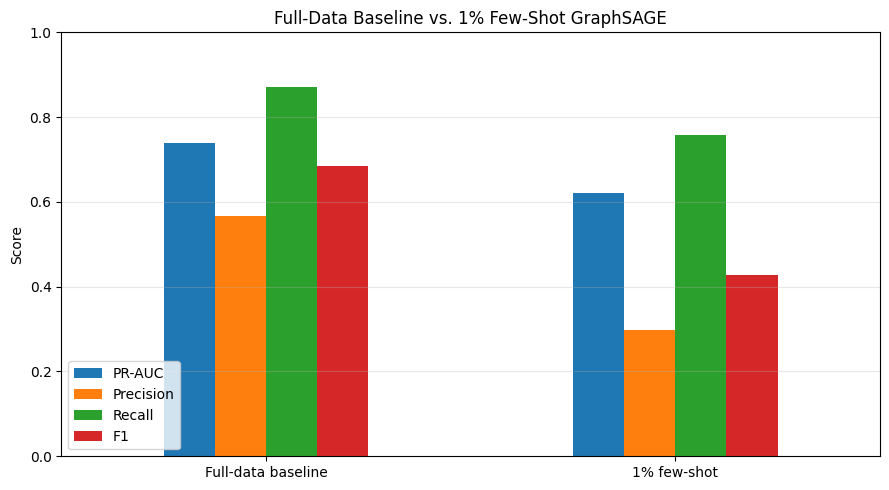

In [ ]:
import matplotlib.pyplot as plt

plot_metrics = [
    "pr_auc",
    "precision",
    "recall",
    "f1"
]

ax = (
    comparison_df
    .set_index("model")[plot_metrics]
    .plot(
        kind="bar",
        figsize=(9, 5),
        rot=0
    )
)

ax.set_title(
    "Full-Data Baseline vs. 1% Few-Shot GraphSAGE"
)
ax.set_ylabel("Score")
ax.set_ylim(0, 1)
ax.set_xlabel("")
ax.legend(
    ["PR-AUC", "Precision", "Recall", "F1"],
    loc="lower left"
)
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

The 1% model reduced labeled attack requirements by approximately 99%, but this came with lower precision, more false alerts, and greater instability. The baseline remains the stronger production model, while the few-shot model demonstrates useful performance when attack labels are extremely limited.

In [ ]:
results_df.to_csv(
    os.path.join(
        MODEL_DIR,
        "fewshot_validation_all_runs.csv"
    ),
    index=False
)

summary_df.to_csv(
    os.path.join(
        MODEL_DIR,
        "fewshot_validation_summary.csv"
    ),
    index=False
)

comparison_df.to_csv(
    os.path.join(
        MODEL_DIR,
        "fewshot_test_comparison.csv"
    ),
    index=False
)

retention_df.to_csv(
    os.path.join(
        MODEL_DIR,
        "fewshot_performance_retention.csv"
    ),
    index=False
)

print("All result tables saved.")

All result tables saved.


In [ ]:
ax.figure.savefig(
    os.path.join(
        MODEL_DIR,
        "baseline_vs_fewshot_test.png"
    ),
    dpi=300,
    bbox_inches="tight"
)